## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Load Datasets

In [75]:
from sqlalchemy import create_engine
import urllib

params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=ARYAS\\SQLEXPRESS;"
    "DATABASE=Ecomm_DB;"
    "Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

sales_df = pd.read_sql("SELECT * FROM Sales_Data_Ecommerce", engine)
promotion_df = pd.read_sql("SELECT * FROM Promotion", engine)

sales_df.head()

,user_id,event_date,Day_of_Week,Channel,event_time,event_hour,event_timezone,event_type,product_id,category_id,category,sub_category1,sub_category2,brand,price,user_session,State,User_Score
0,21342,2019-10-25,Friday,Browser,2026-07-16 14:11:00,14,UTC,View,18680,111,Electronics,smartphone,smartphone,Apple,64.330002,8472453,WA,3
1,25649,2019-10-18,Friday,App,2026-07-16 12:23:39,12,UTC,View,6100,180,Appliances,kitchen,refrigerators,Lg,489.959991,1379135,CA,1
2,36102,2019-11-26,Tuesday,Browser,2026-07-16 11:13:35,11,UTC,View,352,71,Electronics,smartphone,smartphone,Nokia,204.639999,9666123,HI,1
3,38878,2019-11-17,Sunday,Browser,2026-07-16 06:20:37,6,UTC,Purchase,10566,50,Electronics,audio,headphone,Apple,169.350006,11408172,ND,1
4,47492,2019-11-16,Saturday,Browser,2026-07-16 03:07:19,3,UTC,View,1924,115,Computers,notebook,notebook,Lenovo,851.590027,3917052,MD,2


In [77]:
promotion_df.head()

,Promotion_Id,Date,Discount,ProductId
0,NzjwLJ2016,2019-10-01,5%,10566
1,pK8KLJ2016,2019-10-02,8%,1924
2,PmHuil2016,2019-10-03,10%,798
3,IdZiv82016,2019-10-04,5%,956
4,EN4jLJ2016,2019-10-05,10%,10616


## Data Inspection

In [80]:
sales_df.shape, promotion_df.shape

((160000, 18), (61, 4))

In [82]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         160000 non-null  int64         
 1   event_date      160000 non-null  object        
 2   Day_of_Week     160000 non-null  object        
 3   Channel         160000 non-null  object        
 4   event_time      160000 non-null  datetime64[ns]
 5   event_hour      160000 non-null  int64         
 6   event_timezone  160000 non-null  object        
 7   event_type      160000 non-null  object        
 8   product_id      160000 non-null  int64         
 9   category_id     160000 non-null  int64         
 10  category        160000 non-null  object        
 11  sub_category1   160000 non-null  object        
 12  sub_category2   160000 non-null  object        
 13  brand           160000 non-null  object        
 14  price           160000 non-null  flo

In [84]:
sales_df.isnull().sum()

user_id           0
event_date        0
Day_of_Week       0
Channel           0
event_time        0
event_hour        0
event_timezone    0
event_type        0
product_id        0
category_id       0
category          0
sub_category1     0
sub_category2     0
brand             0
price             0
user_session      0
State             0
User_Score        0
dtype: int64

In [86]:
sales_df.duplicated().sum()

38

In [88]:
sales_df.nunique()

user_id           144335
event_date            61
Day_of_Week            7
Channel                2
event_time         64719
event_hour            24
event_timezone         1
event_type             3
product_id         10124
category_id          245
category              12
sub_category1         32
sub_category2         86
brand                 50
price              17750
user_session      157635
State                 51
User_Score             4
dtype: int64

In [90]:
promotion_df.isnull().sum()

Promotion_Id    0
Date            0
Discount        0
ProductId       0
dtype: int64

In [92]:
promotion_df.duplicated().sum()

0

In [94]:
promotion_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Promotion_Id  61 non-null     object
 1   Date          61 non-null     object
 2   Discount      61 non-null     object
 3   ProductId     61 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 2.0+ KB


In [96]:
promotion_df.nunique()

Promotion_Id    16
Date            61
Discount         9
ProductId       61
dtype: int64

## Data Cleaning

In [99]:
sales_df.drop_duplicates(inplace=True)

In [101]:
sales_df.duplicated().sum()

0

In [103]:
# coverting dtype of date column
sales_df['event_date']= pd.to_datetime(sales_df['event_date'])
promotion_df['Date']= pd.to_datetime(promotion_df['Date'])

In [105]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159962 entries, 0 to 159999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         159962 non-null  int64         
 1   event_date      159962 non-null  datetime64[ns]
 2   Day_of_Week     159962 non-null  object        
 3   Channel         159962 non-null  object        
 4   event_time      159962 non-null  datetime64[ns]
 5   event_hour      159962 non-null  int64         
 6   event_timezone  159962 non-null  object        
 7   event_type      159962 non-null  object        
 8   product_id      159962 non-null  int64         
 9   category_id     159962 non-null  int64         
 10  category        159962 non-null  object        
 11  sub_category1   159962 non-null  object        
 12  sub_category2   159962 non-null  object        
 13  brand           159962 non-null  object        
 14  price           159962 non-null  float64 

## Merge Datasets

In [108]:
df= sales_df.merge(promotion_df, left_on=['product_id','event_date'], right_on=['ProductId','Date'], how='left')

In [110]:
df.tail()

,user_id,event_date,Day_of_Week,Channel,event_time,event_hour,event_timezone,event_type,product_id,category_id,...,sub_category2,brand,price,user_session,State,User_Score,Promotion_Id,Date,Discount,ProductId
159957,3982865,2019-11-27,Wednesday,App,2026-07-16 17:50:49,17,UTC,View,564,71,...,smartphone,Huawei,163.880005,3116480,IL,4,NaN,NaT,NaN,NaN
159958,4004840,2019-11-28,Thursday,App,2026-07-16 16:22:25,16,UTC,View,2773,146,...,desktop,Lenovo,745.969971,8173543,OR,1,NaN,NaT,NaN,NaN
159959,4018287,2019-11-29,Friday,App,2026-07-16 08:11:46,8,UTC,View,915,71,...,smartphone,Xiaomi,196.130005,7907717,CT,3,NaN,NaT,NaN,NaN
159960,4025333,2019-11-29,Friday,Browser,2026-07-16 12:29:14,12,UTC,View,707,71,...,smartphone,Samsung,124.529999,12629973,MI,1,NaN,NaT,NaN,NaN
159961,4027388,2019-11-30,Saturday,Browser,2026-07-16 06:38:53,6,UTC,Cart,976,71,...,smartphone,Oppo,308.630005,11229000,AK,3,NaN,NaT,NaN,NaN


In [112]:
df.drop(columns=['ProductId','Date'], inplace=True)

In [114]:
df.columns

Index(['user_id', 'event_date', 'Day_of_Week', 'Channel', 'event_time',
       'event_hour', 'event_timezone', 'event_type', 'product_id',
       'category_id', 'category', 'sub_category1', 'sub_category2', 'brand',
       'price', 'user_session', 'State', 'User_Score', 'Promotion_Id',
       'Discount'],
      dtype='object')

In [116]:
df.columns=df.columns.str.lower()

In [118]:
df.columns

Index(['user_id', 'event_date', 'day_of_week', 'channel', 'event_time',
       'event_hour', 'event_timezone', 'event_type', 'product_id',
       'category_id', 'category', 'sub_category1', 'sub_category2', 'brand',
       'price', 'user_session', 'state', 'user_score', 'promotion_id',
       'discount'],
      dtype='object')

## Feature Engineering

In [121]:
df['revenue']=np.where(df['event_type']=='Purchase', df['price'],0)

In [125]:
df['promotion_flag']=df['promotion_id'].notna()

In [127]:
df['discount'].unique()

array([nan, '20%', '5%', '10%', '25%', '15%', '30%', '8%', '12%'],
      dtype=object)

In [131]:
df['discount']=(df['discount'].str.replace('%','').astype(float))

In [137]:
df.head()

,user_id,event_date,day_of_week,channel,event_time,event_hour,event_timezone,event_type,product_id,category_id,...,sub_category2,brand,price,user_session,state,user_score,promotion_id,discount,revenue,promotion_flag
0,21342,2019-10-25,Friday,Browser,2026-07-16 14:11:00,14,UTC,View,18680,111,...,smartphone,Apple,64.330002,8472453,WA,3,NaN,NaN,0.000000,False
1,25649,2019-10-18,Friday,App,2026-07-16 12:23:39,12,UTC,View,6100,180,...,refrigerators,Lg,489.959991,1379135,CA,1,NaN,NaN,0.000000,False
2,36102,2019-11-26,Tuesday,Browser,2026-07-16 11:13:35,11,UTC,View,352,71,...,smartphone,Nokia,204.639999,9666123,HI,1,NaN,NaN,0.000000,False
3,38878,2019-11-17,Sunday,Browser,2026-07-16 06:20:37,6,UTC,Purchase,10566,50,...,headphone,Apple,169.350006,11408172,ND,1,NaN,NaN,169.350006,False
4,47492,2019-11-16,Saturday,Browser,2026-07-16 03:07:19,3,UTC,View,1924,115,...,notebook,Lenovo,851.590027,3917052,MD,2,NaN,NaN,0.000000,False


## Exploratory Data Analysis (EDA)

In [139]:
df.shape

(159962, 22)

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159962 entries, 0 to 159961
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         159962 non-null  int64         
 1   event_date      159962 non-null  datetime64[ns]
 2   day_of_week     159962 non-null  object        
 3   channel         159962 non-null  object        
 4   event_time      159962 non-null  datetime64[ns]
 5   event_hour      159962 non-null  int64         
 6   event_timezone  159962 non-null  object        
 7   event_type      159962 non-null  object        
 8   product_id      159962 non-null  int64         
 9   category_id     159962 non-null  int64         
 10  category        159962 non-null  object        
 11  sub_category1   159962 non-null  object        
 12  sub_category2   159962 non-null  object        
 13  brand           159962 non-null  object        
 14  price           159962 non-null  flo

In [143]:
df.describe()

,user_id,event_date,event_time,event_hour,product_id,category_id,price,user_session,user_score,discount,revenue
count,1.599620e+05,159962,159962,159962.000000,159962.000000,159962.000000,159962.000000,1.599620e+05,159962.000000,294.000000,159962.000000
mean,1.585049e+06,2019-11-03 20:28:56.692464384,2026-07-16 11:35:40.040390656,11.093303,5202.949588,93.954864,389.792231,7.527564e+06,2.495518,13.724490,35.268730
min,9.900000e+01,2019-10-01 00:00:00,2026-07-16 00:00:11,0.000000,1.000000,0.000000,1.260000,1.500000e+01,1.000000,5.000000,0.000000
25%,5.695408e+05,2019-10-20 00:00:00,2026-07-16 07:18:43.249999872,7.000000,707.000000,71.000000,135.009995,3.743108e+06,1.000000,8.000000,0.000000
50%,1.407376e+06,2019-11-08 00:00:00,2026-07-16 11:39:51,11.000000,1181.500000,71.000000,250.125000,7.543434e+06,2.000000,10.000000,0.000000
75%,2.458183e+06,2019-11-17 00:00:00,2026-07-16 15:51:37,15.000000,7811.000000,115.000000,504.059998,1.129680e+07,3.000000,20.000000,0.000000
max,4.062342e+06,2019-11-30 00:00:00,2026-07-16 23:59:56,23.000000,26295.000000,305.000000,2574.040039,1.506575e+07,4.000000,30.000000,2573.790039
std,1.136526e+06,NaN,NaN,5.227430,6337.773850,55.240731,381.414569,4.352785e+06,1.117754,7.511239,157.269451


In [156]:
df['event_type'].value_counts()

event_type
View        125925
Cart         19409
Purchase     14628
Name: count, dtype: int64

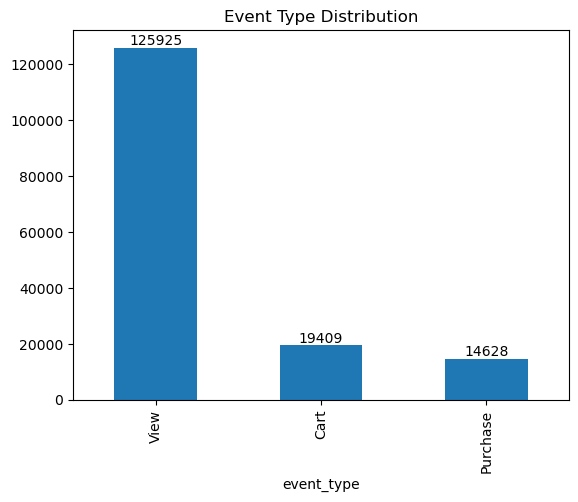

In [162]:
ax=df['event_type'].value_counts().plot(kind='bar')
plt.title('Event Type Distribution')
ax.bar_label(ax.containers[0])
plt.show()

#### - Views dominate customer activity.
#### - Significant drop from View → Cart. Only 19,409 cart events (12.1%).
#### - Cart → Purchase conversion is relatively strong. Purchases: 14,628. About 75% of cart events result in a purchase (14628 / 19409).
#### - The biggest opportunity is increasing the number of users who add products to the cart, since the Cart → Purchase conversion already looks reasonably healthy.

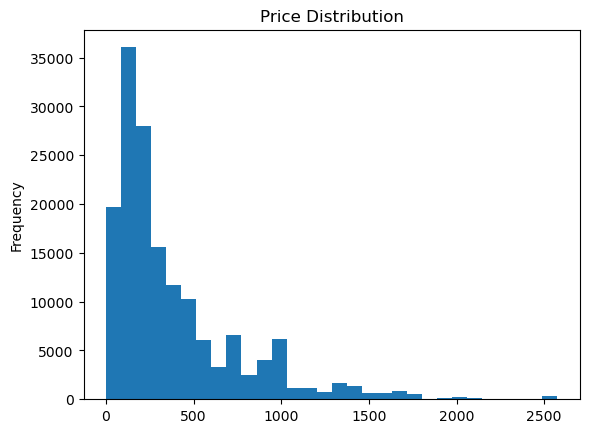

In [ ]:
df['price'].plot(kind='hist', bins=30)
plt.title('Price Distribution')
plt.show()

#### - Most products/events have low prices (roughly below ₹300).
#### - As the price increases, the frequency decreases.
#### - Very expensive products (₹1500+) are rare.

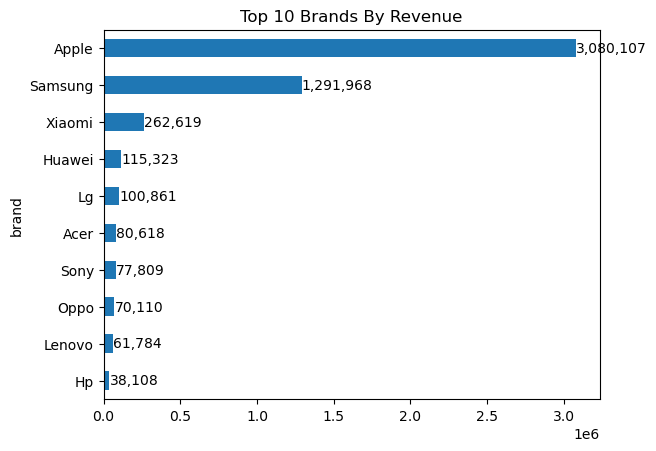

In [208]:
# Brand-wise Revenue
ax=df.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(10)\
.plot(kind='barh')
ax.invert_yaxis()
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title('Top 10 Brands By Revenue')
plt.show()

#### - Apple leads with ₹3.08M, followed by Samsung (₹1.29M).
#### - Apple alone generates over 2× the revenue of Samsung.
#### - The remaining brands each contribute less than ₹0.30M.

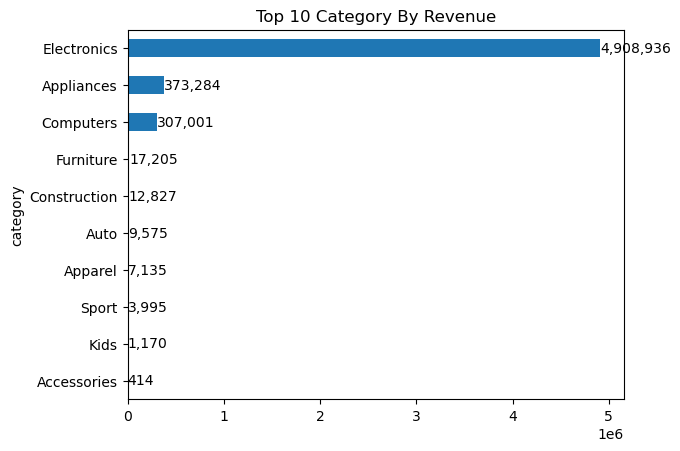

In [210]:
# Category-wise Revenue
ax=df.groupby('category')['revenue'].sum().sort_values(ascending=False).head(10)\
.plot(kind='barh')
ax.invert_yaxis()
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title('Top 10 Category By Revenue')
plt.show()

#### - Electronics dominates with ₹4.97M in revenue.
#### - Appliances (₹0.37M) and Computers (₹0.31M) are distant followers.
#### - Electronics contributes the vast majority of total revenue.

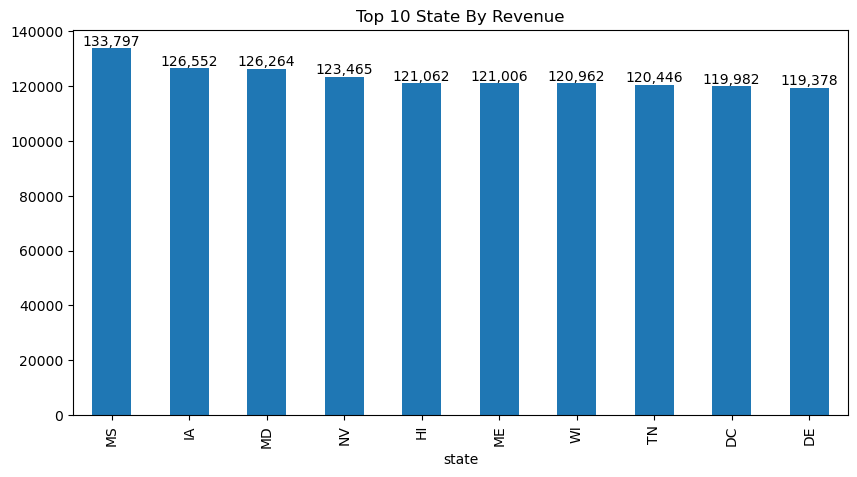

In [224]:
# State-wise Revenue
ax=df.groupby('state')['revenue'].sum().sort_values(ascending=False).head(10)\
.plot(kind='bar',figsize=(10,5))

ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title('Top 10 State By Revenue')
plt.show()

#### - MS records the highest revenue (₹133.8K), followed by IA (₹126.6K) and MD (₹126.3K).
#### - Revenue across the top 10 states ranges from ₹119K–₹134K, indicating balanced regional performance.

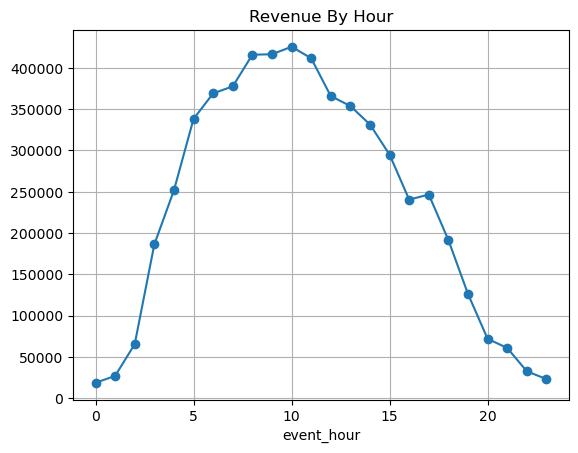

In [244]:
# Hour-wise Revenue
df.groupby('event_hour')['revenue'].sum()\
.plot(kind='line', marker='o')
plt.title('Revenue By Hour')
plt.grid(True)
plt.show()

#### - Revenue peaks between 8 AM and 11 AM, reaching approximately ₹420K/hour.
#### - Revenue declines steadily after noon and falls below ₹100K/hour after 8 PM.
#### - Morning hours are the most profitable sales period.

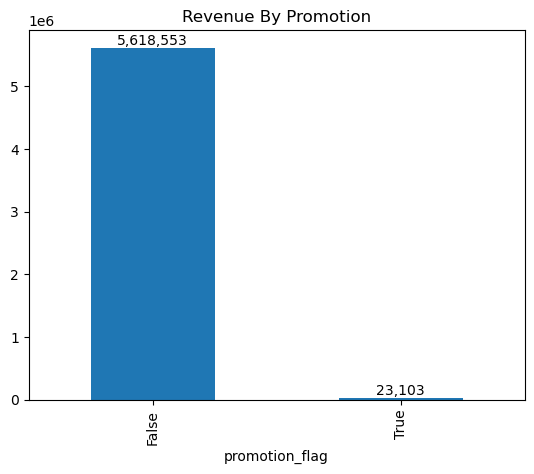

In [258]:
# Promotion vs Non-Promotion Revenue
ax=df.groupby('promotion_flag')['revenue'].sum()\
.plot(kind='bar')
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.title('Revenue By Promotion')
plt.show()

#### - Non-promotional sales: ₹5.62M
#### - Promotional sales: ₹23.1K
#### - Promotions contribute less than 1% of total revenue, indicating minimal impact or limited promotional activity.

In [272]:
df.to_csv('ecommerce_final.csv', index=False)